# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

**Import Libraries**

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, binom, poisson
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score, accuracy_score
import ipywidgets as widgets
from IPython.display import display

# Set Style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.


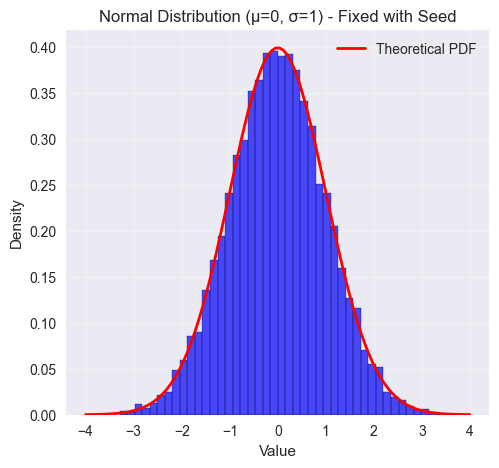

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

mean, std = 0, 1
data = np.random.normal(mean, std, 10000)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(data, bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')

x = np.linspace(-4, 4, 100)
plt.plot(x, norm.pdf(x, mean, std), 'r-', lw=2, label='Theoretical PDF')

plt.title(f'Normal Distribution (μ={mean}, σ={std}) - Fixed with Seed')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?


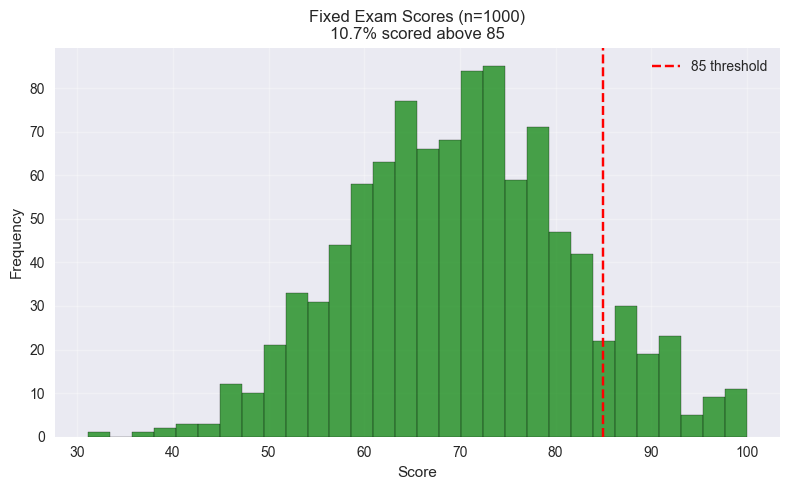

In [65]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) 

# 2. Data generation
scores = np.random.normal(70, 12, 1000)
scores = np.clip(scores, 0, 100)

above_85 = np.sum(scores > 85)
percentage = (above_85 / 1000) * 100

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.hist(scores, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(85, color='red', linestyle='--', label='85 threshold')
plt.title(f'Fixed Exam Scores (n=1000)\n{percentage:.1f}% scored above 85')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.


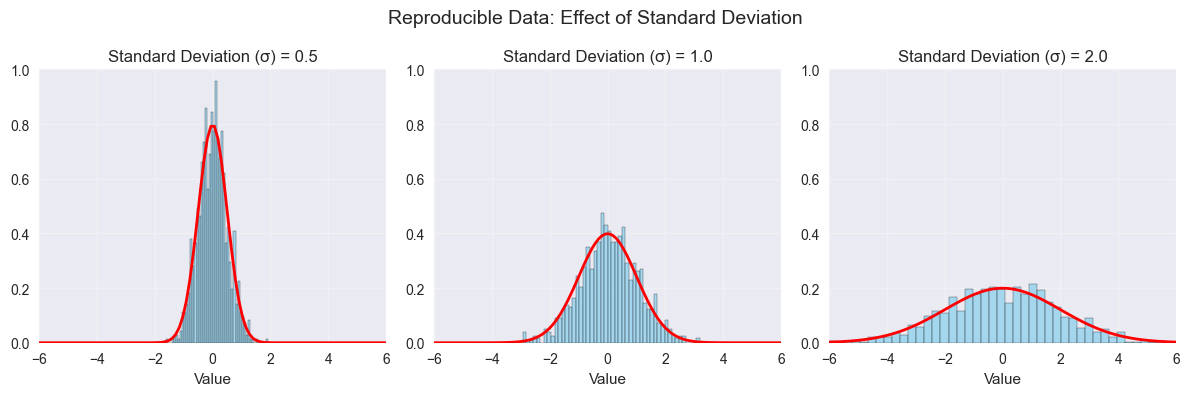

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# data will fix by setting the Seed
np.random.seed(42) 

plt.figure(figsize=(12, 4))
for i, std_val in enumerate([0.5, 1.0, 2.0]):
    data_std = np.random.normal(0, std_val, 1000)
    
    plt.subplot(1, 3, i+1)
    plt.hist(data_std, bins=50, density=True, alpha=0.7, edgecolor='black', color='skyblue')
    
    x = np.linspace(-6, 6, 100)
    plt.plot(x, norm.pdf(x, 0, std_val), 'r-', lw=2)
    
    plt.title(f'Standard Deviation (σ) = {std_val}')
    plt.xlabel('Value')
    plt.xlim(-6, 6)
    plt.ylim(0, 1.0) 
    plt.grid(True, alpha=0.3)

plt.suptitle('Reproducible Data: Effect of Standard Deviation', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.


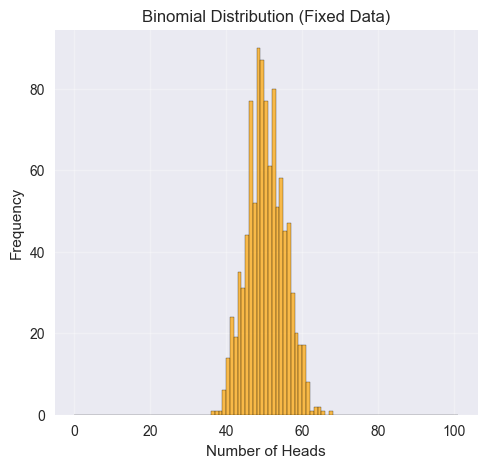

In [67]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) 

n_trials = 100
p = 0.5
n_experiments = 1000

coin_tosses = np.random.binomial(n_trials, p, n_experiments)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(coin_tosses, bins=range(0, n_trials + 2), alpha=0.7, color='orange', edgecolor='black')
plt.title(f'Binomial Distribution (Fixed Data)')
plt.xlabel('Number of Heads')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?


Probability of getting exactly 6 correct: 0.0162


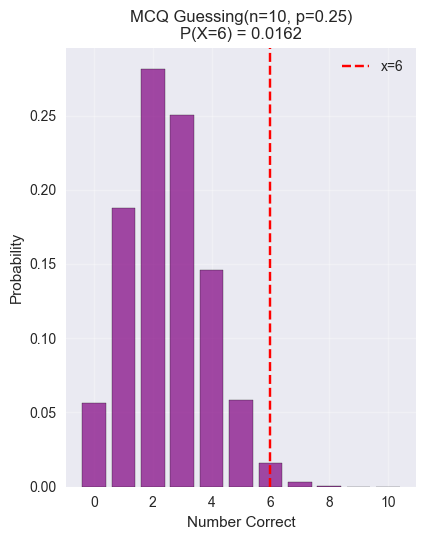

In [68]:
n_questions = 10
p_correct = 0.25
prob_exact_6 = binom.pmf(6, n_questions, p_correct)

x = np.arange(0,11)
pmf = binom.pmf(x, n_questions, p_correct)

plt.subplot(1, 2, 2)
plt.bar(x, pmf, alpha=0.7, color='purple', edgecolor='black')
plt.axvline(x=6, color='red', linestyle='--', label='x=6')
plt.title(f'MCQ Guessing(n={n_questions}, p={p_correct})\nP(X=6) = {prob_exact_6:.4f}')
plt.xlabel('Number Correct')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Probability of getting exactly 6 correct: {prob_exact_6:.4f}")

plt.tight_layout()
plt.show()

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

Binomial resembles normal when n is large (typically n*p > 5 and n*(1-p) > 5)


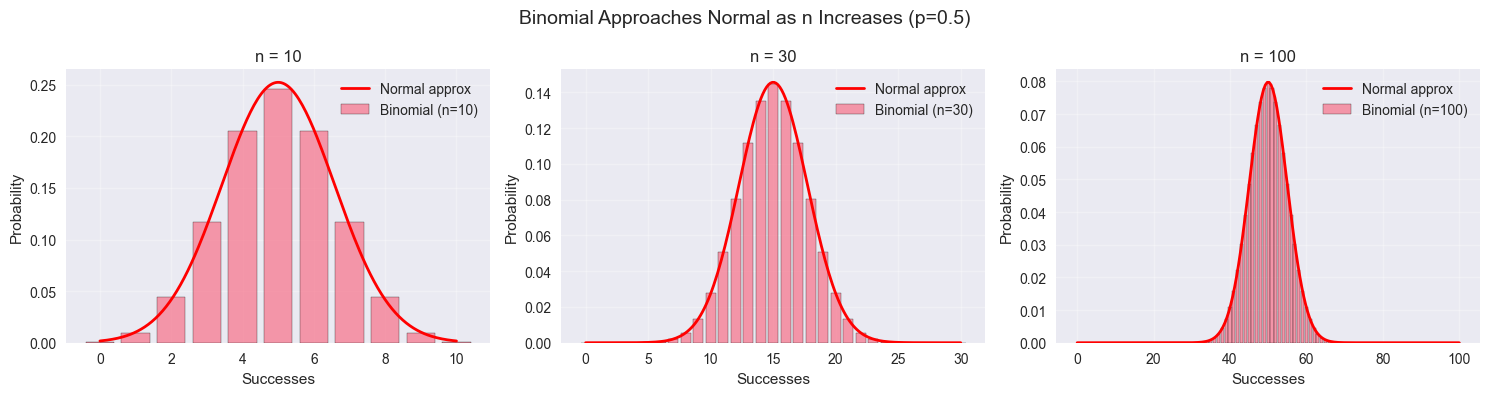

In [69]:
plt.figure(figsize=(15, 4))
n_values = [10, 30, 100]
p = 0.5

for i, n in enumerate(n_values):
    x = np.arange(0, n+1)
    binom_pmf = binom.pmf(x, n, p)
    
    plt.subplot(1, 3, i+1)
    plt.bar(x, binom_pmf, alpha=0.7, label=f'Binomial (n={n})', edgecolor='black')
    
    # Normal approximation
    mu = n * p
    sigma = np.sqrt(n * p * (1-p))
    x_norm = np.linspace(0, n, 200)
    plt.plot(x_norm, norm.pdf(x_norm, mu, sigma), 'r-', lw=2, label='Normal approx')
    
    plt.title(f'n = {n}')
    plt.xlabel('Successes')
    plt.ylabel('Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)

print("Binomial resembles normal when n is large (typically n*p > 5 and n*(1-p) > 5)")
plt.suptitle('Binomial Approaches Normal as n Increases (p=0.5)', fontsize=14)
plt.tight_layout()
plt.show()


## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).


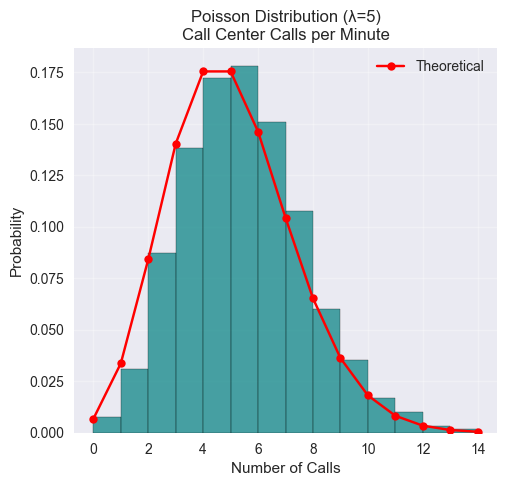

In [70]:
lambda_calls = 5
calls_per_minute = np.random.poisson(lambda_calls, 10000)

np.random.seed(42) 

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(calls_per_minute, bins=range(0, 15), alpha=0.7, color='teal', edgecolor='black', density=True)

x = np.arange(0, 15)
poisson_pmf = poisson.pmf(x, lambda_calls)
plt.plot(x, poisson_pmf, 'ro-', markersize=6, label='Theoretical')

plt.title(f'Poisson Distribution (λ={lambda_calls})\nCall Center Calls per Minute')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

**Q8:** What is probability of receiving exactly 3 calls in a minute?


Probability of receiving exactly 3 calls: 0.1404


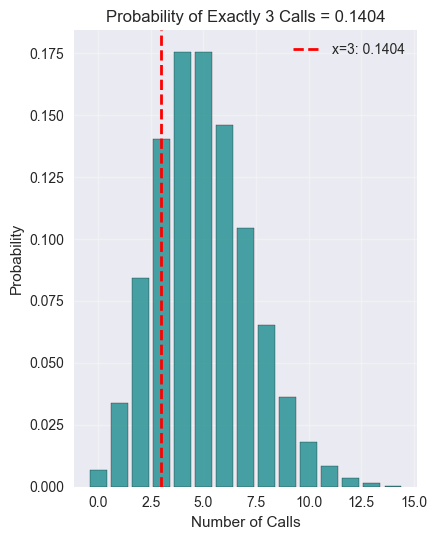

In [71]:
prob_3_calls = poisson.pmf(3, lambda_calls)

plt.subplot(1, 2, 2)
plt.bar(x, poisson_pmf, alpha=0.7, color='teal', edgecolor='black')
plt.axvline(x=3, color='red', linestyle='--', linewidth=2, label=f'x=3: {prob_3_calls:.4f}')
plt.title(f'Probability of Exactly 3 Calls = {prob_3_calls:.4f}')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Probability of receiving exactly 3 calls: {prob_3_calls:.4f}")

plt.tight_layout()
plt.show()


**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

Use Poisson for rare events in large population, Binomial for fixed trials with success/failure


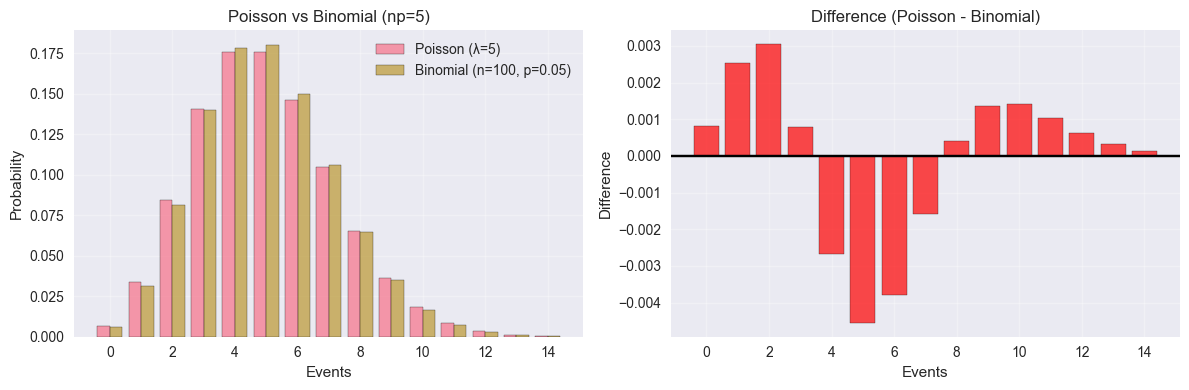

In [72]:
plt.figure(figsize=(12, 4))

# Poisson with λ = 5
x_pois = np.arange(0, 15)
pois_pmf = poisson.pmf(x_pois, 5)

# Binomial with n=100, p=0.05 (np = 5)
n_binom, p_binom = 100, 0.05
binom_pmf = binom.pmf(x_pois, n_binom, p_binom)

plt.subplot(1, 2, 1)
plt.bar(x_pois - 0.2, pois_pmf, width=0.4, alpha=0.7, label='Poisson (λ=5)', edgecolor='black')
plt.bar(x_pois + 0.2, binom_pmf, width=0.4, alpha=0.7, label='Binomial (n=100, p=0.05)', edgecolor='black')
plt.title('Poisson vs Binomial (np=5)')
plt.xlabel('Events')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(x_pois, pois_pmf - binom_pmf, alpha=0.7, color='red', edgecolor='black')
plt.title('Difference (Poisson - Binomial)')
plt.xlabel('Events')
plt.ylabel('Difference')
plt.axhline(y=0, color='black', linestyle='-')
plt.grid(True, alpha=0.3)

print("Use Poisson for rare events in large population, Binomial for fixed trials with success/failure")

plt.tight_layout()
plt.show()

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.


In [73]:
# Your code here
np.random.seed(42)
n_samples = 1000

# Generate features
X1 = np.random.normal(0, 1, n_samples)
X2 = np.random.poisson(3, n_samples)
X3 = np.random.binomial(1, 0.4, n_samples)

# Create target following a distribution
# Target: 1 if X1 > 0.5 or X2 > 4, else 0
y = ((X1 > 0.5) | (X2 > 4) | (X3 == 1)).astype(int)

# Add some noise
noise = np.random.binomial(1, 0.1, n_samples)
y = np.logical_xor(y, noise).astype(int)

print("Synthetic dataset created")
print(f"Shape: X={n_samples} samples, y distribution: {np.bincount(y)}")

Synthetic dataset created
Shape: X=1000 samples, y distribution: [376 624]


**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

In [74]:
X = np.column_stack([X1, X2, X3])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n Pipeline Results")
print(f"Accuracy: {accuracy:.3f}")
print("Pipeline steps: StandardScaler → LogisticRegression")


 Pipeline Results
Accuracy: 0.830
Pipeline steps: StandardScaler → LogisticRegression


**Q12 (Challenge):** Identify which distribution best fits given dataset.

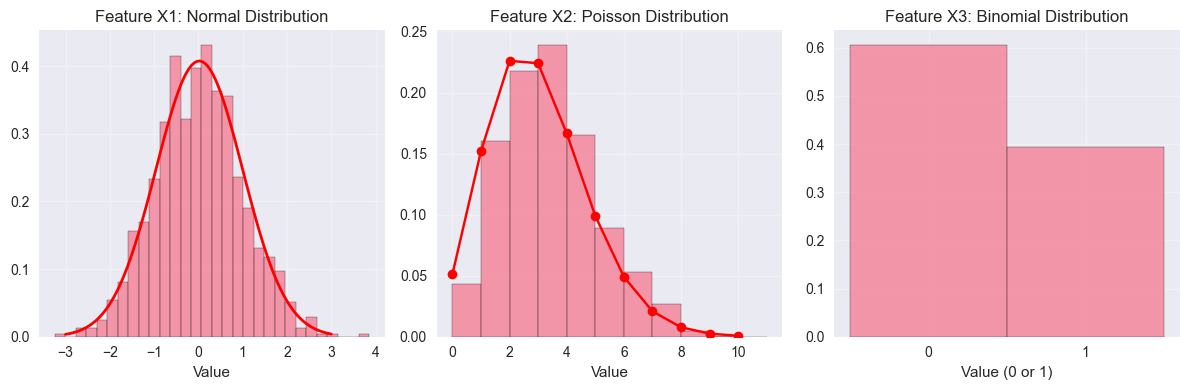


Feature distributions identified: X1-Normal, X2-Poisson, X3-Binomial


In [75]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(X1, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-3, 3, 100)
plt.plot(x, norm.pdf(x, np.mean(X1), np.std(X1)), 'r-', lw=2)
plt.title('Feature X1: Normal Distribution')
plt.xlabel('Value')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.hist(X2, bins=range(0, 12), density=True, alpha=0.7, edgecolor='black')
x_pois = np.arange(0, 11)
plt.plot(x_pois, poisson.pmf(x_pois, np.mean(X2)), 'ro-')
plt.title('Feature X2: Poisson Distribution')
plt.xlabel('Value')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.hist(X3, bins=[-0.5, 0.5, 1.5], density=True, alpha=0.7, edgecolor='black')
plt.title('Feature X3: Binomial Distribution')
plt.xlabel('Value (0 or 1)')
plt.xticks([0, 1])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nFeature distributions identified: X1-Normal, X2-Poisson, X3-Binomial")

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


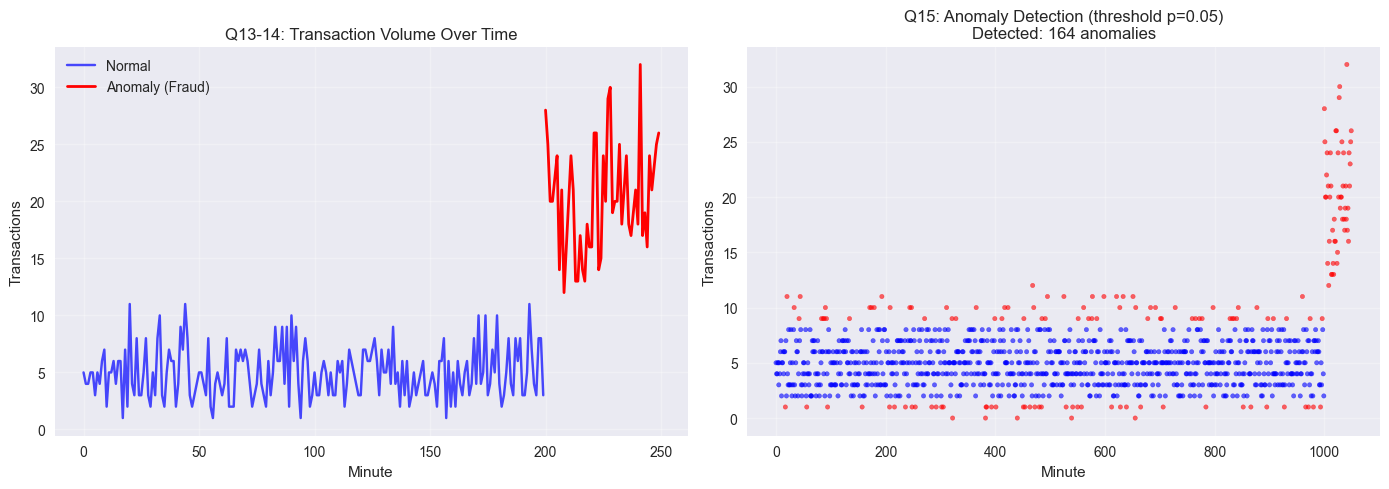


Fraud Detection Results:
True Positives: 50/50 (100.0%)
False Positives: 114
False Negatives: 0

Q16: Ways to reduce false positives:
1. Use moving average with longer time windows
2. Implement dynamic threshold based on time of day
3. Combine with other features (user behavior, location, etc.)
4. Use machine learning with multiple features
5. Implement anomaly detection with confidence intervals


In [76]:
# Q13: Simulate normal transaction behavior
np.random.seed(42)
lambda_normal = 5
normal_minutes = 1000
normal_transactions = np.random.poisson(lambda_normal, normal_minutes)

# Q14: Inject anomalies
anomaly_minutes = 50
anomaly_intensity = np.random.poisson(20, anomaly_minutes)  # Much higher transaction rate

# Combine normal and anomaly data
all_transactions = np.concatenate([normal_transactions, anomaly_intensity])
time_labels = np.concatenate([np.zeros(normal_minutes), np.ones(anomaly_minutes)])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(normal_transactions[:200], 'b-', alpha=0.7, label='Normal')
plt.plot(range(200, 200+50), anomaly_intensity, 'r-', label='Anomaly (Fraud)', linewidth=2)
plt.title('Q13-14: Transaction Volume Over Time')
plt.xlabel('Minute')
plt.ylabel('Transactions')
plt.legend()
plt.grid(True, alpha=0.3)

# Q15: Detect anomalies using Poisson probability threshold
threshold_prob = 0.05  # 5% probability threshold
detected_anomalies = []

for i, txn in enumerate(all_transactions):
    # Probability of observing this many transactions under normal conditions
    prob = poisson.pmf(txn, lambda_normal)
    if prob < threshold_prob:
        detected_anomalies.append(i)

plt.subplot(1, 2, 2)
plt.scatter(range(len(all_transactions)), all_transactions, 
           c=['red' if i in detected_anomalies else 'blue' 
              for i in range(len(all_transactions))], 
           alpha=0.6, s=10)
plt.title(f'Q15: Anomaly Detection (threshold p={threshold_prob})\nDetected: {len(detected_anomalies)} anomalies')
plt.xlabel('Minute')
plt.ylabel('Transactions')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate detection metrics
true_positives = sum(1 for i in detected_anomalies if i >= normal_minutes)
false_positives = sum(1 for i in detected_anomalies if i < normal_minutes)
false_negatives = anomaly_minutes - true_positives

print(f"\nFraud Detection Results:")
print(f"True Positives: {true_positives}/{anomaly_minutes} ({true_positives/anomaly_minutes*100:.1f}%)")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

# Q16: Reducing false positives
print("\nQ16: Ways to reduce false positives:")
print("1. Use moving average with longer time windows")
print("2. Implement dynamic threshold based on time of day")
print("3. Combine with other features (user behavior, location, etc.)")
print("4. Use machine learning with multiple features")
print("5. Implement anomaly detection with confidence intervals")

## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [77]:
# Q17: Interactive sliders
def plot_distributions(mu, sigma, lam):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Normal distribution
    x_norm = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    axes[0].plot(x_norm, norm.pdf(x_norm, mu, sigma), 'b-', lw=2)
    axes[0].fill_between(x_norm, 0, norm.pdf(x_norm, mu, sigma), alpha=0.3)
    axes[0].set_title(f'Normal (μ={mu:.1f}, σ={sigma:.2f})')
    axes[0].grid(True, alpha=0.3)
    
    # Binomial distribution
    n_binom = 20
    p_binom = 0.5
    x_binom = np.arange(0, n_binom+1)
    axes[1].bar(x_binom, binom.pmf(x_binom, n_binom, p_binom), alpha=0.7)
    axes[1].set_title(f'Binomial (n={n_binom}, p={p_binom})')
    axes[1].grid(True, alpha=0.3)
    
    # Poisson distribution
    x_pois = np.arange(0, int(lam*2)+5)
    axes[2].bar(x_pois, poisson.pmf(x_pois, lam), alpha=0.7, color='green')
    axes[2].set_title(f'Poisson (λ={lam:.1f})')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Create interactive widgets
mu_slider = widgets.FloatSlider(value=0, min=-3, max=3, step=0.1, description='μ:')
sigma_slider = widgets.FloatSlider(value=1, min=0.1, max=3, step=0.1, description='σ:')
lambda_slider = widgets.FloatSlider(value=5, min=1, max=15, step=0.5, description='λ:')

interactive_plot = widgets.interactive(plot_distributions, mu=mu_slider, sigma=sigma_slider, lam=lambda_slider)
display(interactive_plot)
print("Interactive visualization created - adjust sliders to see changes")

interactive(children=(FloatSlider(value=0.0, description='μ:', max=3.0, min=-3.0), FloatSlider(value=1.0, desc…

Interactive visualization created - adjust sliders to see changes


## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


Q18-19: Best fitting distribution: Poisson
Log-likelihoods:
  Normal:   -2613.65
  Poisson:  -2604.55
  Binomial: -2775.19


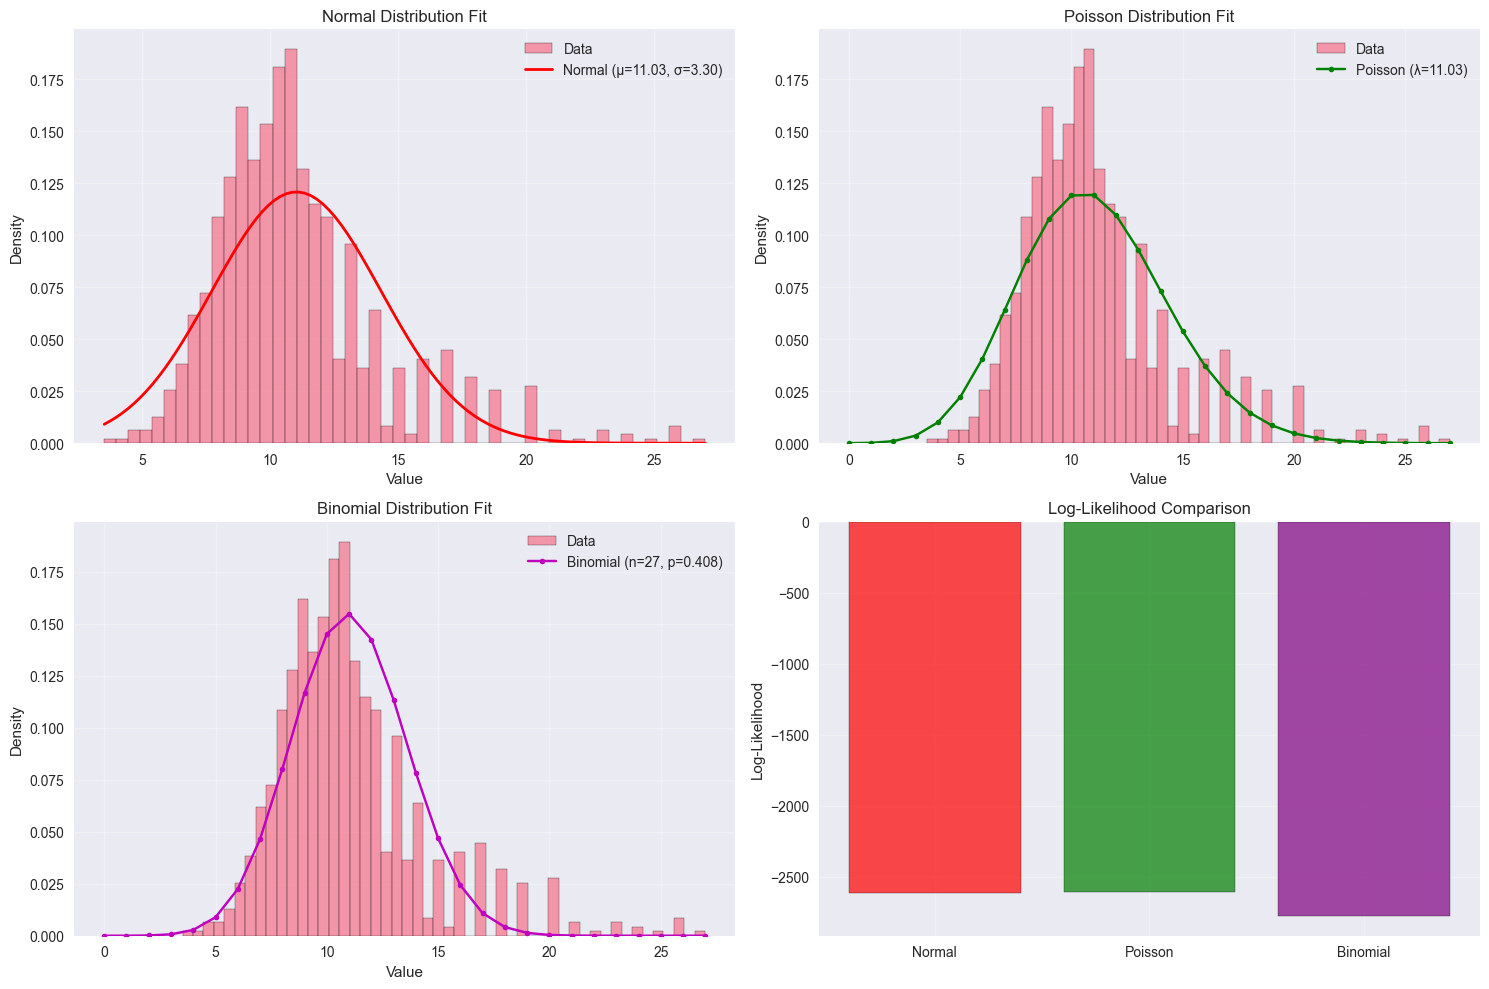

In [78]:
# Q18-19: Distribution fitting
np.random.seed(42)

# Generate a sample dataset (mixture for demonstration)
sample_data = np.concatenate([
    np.random.normal(10, 2, 800),
    np.random.poisson(15, 200)
])

plt.figure(figsize=(15, 10))

# Fit distributions
# Normal
mu_fit, sigma_fit = norm.fit(sample_data)

# Poisson (for integer data)
poisson_fit = np.mean(sample_data)

# Binomial (need n and p)
n_est = int(np.max(sample_data))
p_est = np.mean(sample_data) / n_est
p_est = np.clip(p_est, 0.01, 0.99)  # Ensure valid probability

# Plot histogram with fitted distributions
plt.subplot(2, 2, 1)
plt.hist(sample_data, bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')
x_norm = np.linspace(min(sample_data), max(sample_data), 100)
plt.plot(x_norm, norm.pdf(x_norm, mu_fit, sigma_fit), 'r-', lw=2, label=f'Normal (μ={mu_fit:.2f}, σ={sigma_fit:.2f})')
plt.title('Normal Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(sample_data, bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')
x_pois = np.arange(0, int(np.max(sample_data))+1)
plt.plot(x_pois, poisson.pmf(x_pois, poisson_fit), 'g-o', markersize=4, label=f'Poisson (λ={poisson_fit:.2f})')
plt.title('Poisson Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(sample_data, bins=50, density=True, alpha=0.7, edgecolor='black', label='Data')
x_binom = np.arange(0, n_est+1)
plt.plot(x_binom, binom.pmf(x_binom, n_est, p_est), 'm-o', markersize=4, label=f'Binomial (n={n_est}, p={p_est:.3f})')
plt.title('Binomial Distribution Fit')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

# Q19: Likelihood comparison
normal_log_likelihood = np.sum(np.log(norm.pdf(sample_data, mu_fit, sigma_fit) + 1e-10))
poisson_log_likelihood = np.sum(np.log(poisson.pmf(sample_data.astype(int), poisson_fit) + 1e-10))
binom_log_likelihood = np.sum(np.log(binom.pmf(sample_data.astype(int), n_est, p_est) + 1e-10))

plt.subplot(2, 2, 4)
likelihoods = [normal_log_likelihood, poisson_log_likelihood, binom_log_likelihood]
labels = ['Normal', 'Poisson', 'Binomial']
colors = ['red', 'green', 'purple']
plt.bar(labels, likelihoods, color=colors, alpha=0.7, edgecolor='black')
plt.title('Log-Likelihood Comparison')
plt.ylabel('Log-Likelihood')
plt.grid(True, alpha=0.3)

best_fit = labels[np.argmax(likelihoods)]
print(f"Q18-19: Best fitting distribution: {best_fit}")
print(f"Log-likelihoods:")
print(f"  Normal:   {normal_log_likelihood:.2f}")
print(f"  Poisson:  {poisson_log_likelihood:.2f}")
print(f"  Binomial: {binom_log_likelihood:.2f}")

plt.tight_layout()
plt.show()

## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


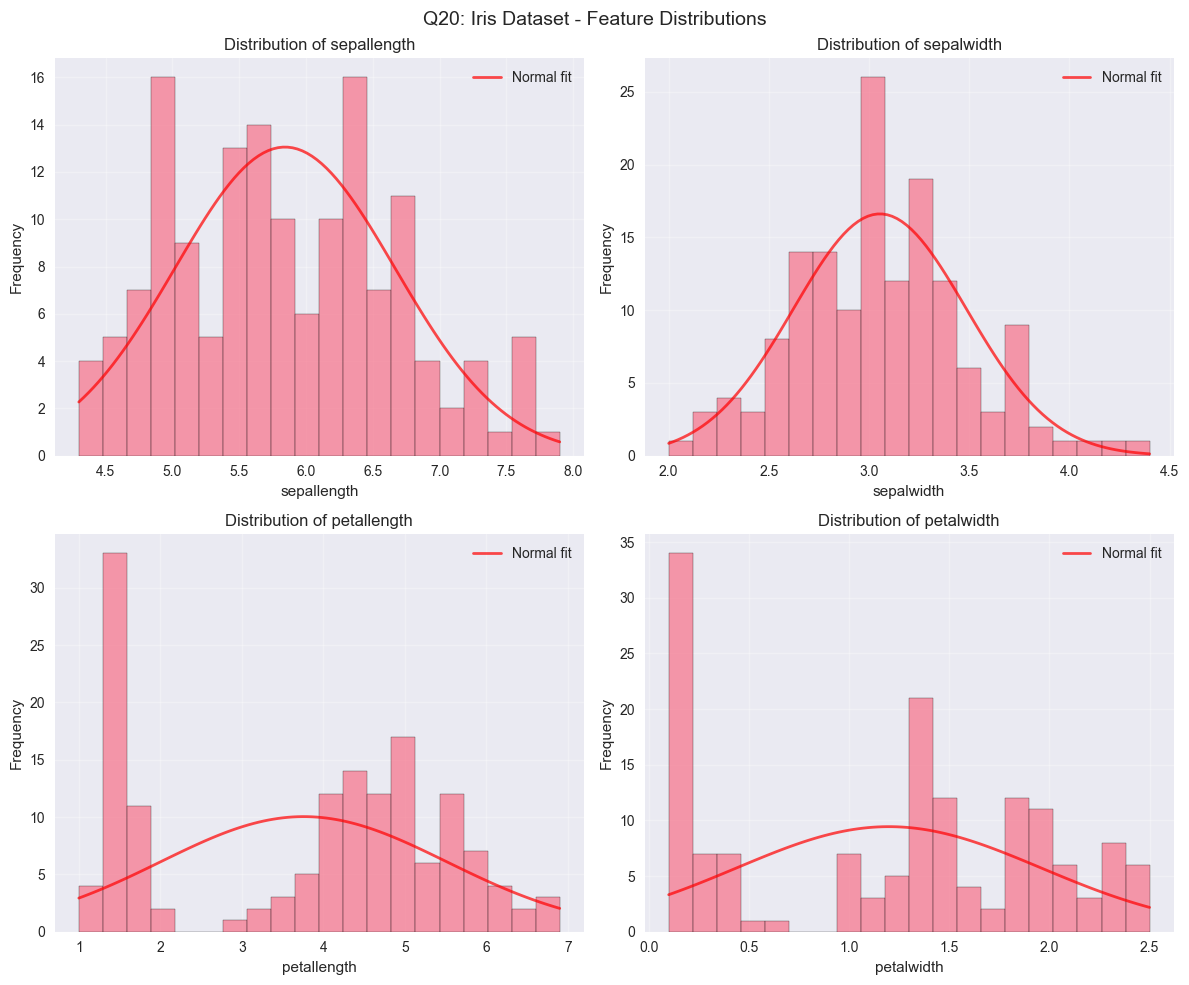


Q21: Distribution analysis for Iris dataset:

sepallength:
  Shapiro-Wilk test p-value: 0.0102
  Not normal distribution

sepalwidth:
  Shapiro-Wilk test p-value: 0.0752
  Normal distribution

petallength:
  Shapiro-Wilk test p-value: 0.0000
  Not normal distribution

petalwidth:
  Shapiro-Wilk test p-value: 0.0000
  Not normal distribution

Q22: ML Model Results
Model: Random Forest Classifier
Accuracy: 1.000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



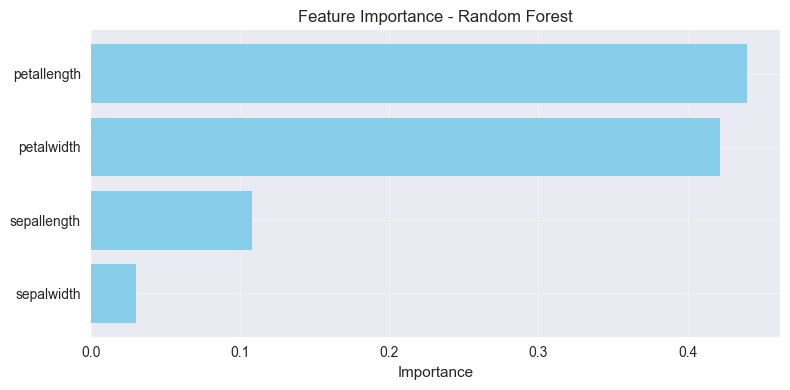

In [80]:
# Q20-22: Real dataset integration
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Load a real dataset (using Iris as example)
iris = fetch_openml('iris', version=1, as_frame=True)
X_iris = iris.data
y_iris = iris.target

# Analyze feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = X_iris.columns

for i, (ax, feature) in enumerate(zip(axes.flat, features)):
    ax.hist(X_iris[feature], bins=20, alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    
    # Fit normal distribution
    mu, sigma = norm.fit(X_iris[feature])
    x = np.linspace(min(X_iris[feature]), max(X_iris[feature]), 100)
    ax.plot(x, norm.pdf(x, mu, sigma) * len(X_iris[feature]) * (max(X_iris[feature]) - min(X_iris[feature])) / 20, 
            'r-', lw=2, alpha=0.7, label=f'Normal fit')
    ax.legend()

plt.suptitle('Q20: Iris Dataset - Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

# Q21: Identify best distribution for each feature
print("\nQ21: Distribution analysis for Iris dataset:")
for feature in features:
    data = X_iris[feature]
    # Test normality using Shapiro-Wilk
    shapiro_stat, shapiro_p = stats.shapiro(data)
    print(f"\n{feature}:")
    print(f"  Shapiro-Wilk test p-value: {shapiro_p:.4f}")
    print(f"  {'Normal' if shapiro_p > 0.05 else 'Not normal'} distribution")

# Q22: Build ML model
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("\nQ22: ML Model Results")
print(f"Model: Random Forest Classifier")
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
class_names = sorted(y_iris.unique())
print(classification_report(y_test, y_pred, labels=class_names, target_names=class_names))

# Feature importance
importances = rf_model.feature_importances_
feature_imp_df = pd.DataFrame({'feature': features, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(feature_imp_df['feature'], feature_imp_df['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()